<a href="https://colab.research.google.com/github/Fouzia13352/MLOPS1/blob/main/CSE_Employability_Skill_Gap_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
technical_skills = [
    "Python",
    "Java",
    "C++",
    "Data_Structures",
    "Algorithms",
    "DBMS",
    "SQL",
    "Machine_Learning",
    "Cloud_Computing",
    "Cybersecurity",
    "Web_Development"
]

soft_skills = [
    "Communication",
    "Problem_Solving",
    "Teamwork"
]

all_skills = technical_skills + soft_skills

print("Number of skills:", len(all_skills))
print(all_skills)

Number of skills: 14
['Python', 'Java', 'C++', 'Data_Structures', 'Algorithms', 'DBMS', 'SQL', 'Machine_Learning', 'Cloud_Computing', 'Cybersecurity', 'Web_Development', 'Communication', 'Problem_Solving', 'Teamwork']


In [ ]:
industry_demand = {
    "Python": 85,
    "Java": 75,
    "C++": 70,
    "Data_Structures": 90,
    "Algorithms": 88,
    "DBMS": 82,
    "SQL": 84,
    "Machine_Learning": 80,
    "Cloud_Computing": 78,
    "Cybersecurity": 70,
    "Web_Development": 78,
    "Communication": 80,
    "Problem_Solving": 90,
    "Teamwork": 78
}

industry_demand_df = pd.DataFrame(
    list(industry_demand.items()),
    columns=["Skill", "Industry_Demand"]
)

industry_demand_df

,Skill,Industry_Demand
0,Python,85
1,Java,75
2,C++,70
3,Data_Structures,90
4,Algorithms,88
5,DBMS,82
6,SQL,84
7,Machine_Learning,80
8,Cloud_Computing,78
9,Cybersecurity,70


In [ ]:
n_students = 1000

data = {}

for skill in all_skills:
    data[skill] = np.clip(
        np.random.normal(
            loc=65,
            scale=15,
            size=n_students
        ),
        0,
        100
    )

df = pd.DataFrame(data)

df.insert(
    0,
    "Student_ID",
    [f"CSE_{i:04d}" for i in range(1, n_students + 1)]
)

df.head()

,Student_ID,Python,Java,C++,Data_Structures,Algorithms,DBMS,SQL,Machine_Learning,Cloud_Computing,Cybersecurity,Web_Development,Communication,Problem_Solving,Teamwork
0,CSE_0001,72.450712,85.990332,54.872326,36.382887,52.047596,58.643605,48.288780,76.777776,64.504621,76.481032,54.822579,47.327305,82.622211,65.176046
1,CSE_0002,62.926035,78.869505,62.832220,52.094225,64.531948,58.198788,55.536037,38.334786,57.445246,81.101191,60.417508,71.492756,36.815286,72.911580
2,CSE_0003,74.715328,65.894456,53.113701,58.795917,65.270253,38.065352,50.869097,75.721185,62.414376,72.480349,56.039284,81.661298,60.083074,40.834958
3,CSE_0004,87.845448,55.295948,60.380577,93.315315,72.089455,60.048647,56.780063,61.494139,75.720976,35.862535,66.656271,76.327775,64.375100,51.201527
4,CSE_0005,61.487699,75.473350,36.595780,73.348297,44.497125,75.992436,61.787745,75.611866,84.167850,62.668664,82.957678,81.267163,65.238630,62.777322


In [ ]:
df["CGPA"] = np.clip(
    np.random.normal(7.5, 0.8, n_students),
    5.0,
    10.0
)

df["Projects"] = np.random.poisson(3, n_students)

df["Internship"] = np.random.binomial(1, 0.45, n_students)

df["Certifications"] = np.random.poisson(2, n_students)

df.head()

,Student_ID,Python,Java,C++,Data_Structures,Algorithms,DBMS,SQL,Machine_Learning,Cloud_Computing,Cybersecurity,Web_Development,Communication,Problem_Solving,Teamwork,CGPA,Projects,Internship,Certifications
0,CSE_0001,72.450712,85.990332,54.872326,36.382887,52.047596,58.643605,48.288780,76.777776,64.504621,76.481032,54.822579,47.327305,82.622211,65.176046,7.320607,1,0,1
1,CSE_0002,62.926035,78.869505,62.832220,52.094225,64.531948,58.198788,55.536037,38.334786,57.445246,81.101191,60.417508,71.492756,36.815286,72.911580,7.331332,3,1,4
2,CSE_0003,74.715328,65.894456,53.113701,58.795917,65.270253,38.065352,50.869097,75.721185,62.414376,72.480349,56.039284,81.661298,60.083074,40.834958,9.288342,2,0,2
3,CSE_0004,87.845448,55.295948,60.380577,93.315315,72.089455,60.048647,56.780063,61.494139,75.720976,35.862535,66.656271,76.327775,64.375100,51.201527,8.147449,3,0,0
4,CSE_0005,61.487699,75.473350,36.595780,73.348297,44.497125,75.992436,61.787745,75.611866,84.167850,62.668664,82.957678,81.267163,65.238630,62.777322,9.484521,2,0,4


In [ ]:
for skill in all_skills:
    df[f"{skill}_Gap"] = np.maximum(
        industry_demand[skill] - df[skill],
        0
    )

In [ ]:
gap_columns = [f"{skill}_Gap" for skill in all_skills]

df["Overall_Gap"] = df[gap_columns].mean(axis=1)

df[[
    "Student_ID",
    "Overall_Gap"
]].head()

,Student_ID,Overall_Gap
0,CSE_0001,19.220254
1,CSE_0002,20.675970
2,CSE_0003,19.727358
3,CSE_0004,15.483356
4,CSE_0005,14.071031


In [ ]:
df["Employability_Status"] = np.where(
    df["Overall_Gap"] < 20,
    1,
    0
)

df["Employability_Status"].value_counts()

,count
Employability_Status,
1,798
0,202


In [ ]:
df.shape

(1000, 35)

In [ ]:
df.describe()

,Python,Java,C++,Data_Structures,Algorithms,DBMS,SQL,Machine_Learning,Cloud_Computing,Cybersecurity,...,SQL_Gap,Machine_Learning_Gap,Cloud_Computing_Gap,Cybersecurity_Gap,Web_Development_Gap,Communication_Gap,Problem_Solving_Gap,Teamwork_Gap,Overall_Gap,Employability_Status
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,65.230348,66.012936,65.012630,64.680307,64.219167,64.230729,64.515582,65.214699,65.214975,64.808982,...,20.213827,16.184594,14.408758,8.714189,14.988507,16.453776,25.133052,13.948036,17.059600,0.798000
std,14.520847,14.835211,14.539408,15.303975,14.772648,14.931578,15.213001,15.444509,15.017249,14.449455,...,13.948157,13.338988,12.634355,10.318859,12.430446,13.158934,14.028646,12.540087,3.393165,0.401693
min,16.380990,20.894170,19.707318,21.058270,17.349443,21.507292,24.310812,9.674521,7.450167,6.163996,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.428252,0.000000
25%,55.286145,55.906375,55.280006,53.938693,54.760926,54.594608,53.672940,54.617656,55.447182,55.349988,...,8.503824,4.148982,2.841939,0.000000,3.814974,5.476397,15.036989,1.940960,14.803120,1.000000
50%,65.379509,65.946157,64.996239,65.002769,64.726370,64.357594,64.178804,65.074696,65.286860,65.065492,...,19.821196,14.925304,12.713140,4.934508,13.844713,15.484045,24.833952,11.791597,16.861394,1.000000
75%,74.719158,75.933233,74.913730,75.004181,74.586847,74.186703,75.496176,75.851018,75.158061,74.761132,...,30.327060,25.382344,22.552818,14.650012,23.303492,24.867910,34.726570,22.450390,19.364697,1.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,59.689188,70.325479,70.549833,63.836004,61.488481,65.633687,66.744406,59.238433,28.349149,1.000000


In [ ]:
df["Employability_Status"].value_counts(normalize=True)

,proportion
Employability_Status,
1,0.798
0,0.202


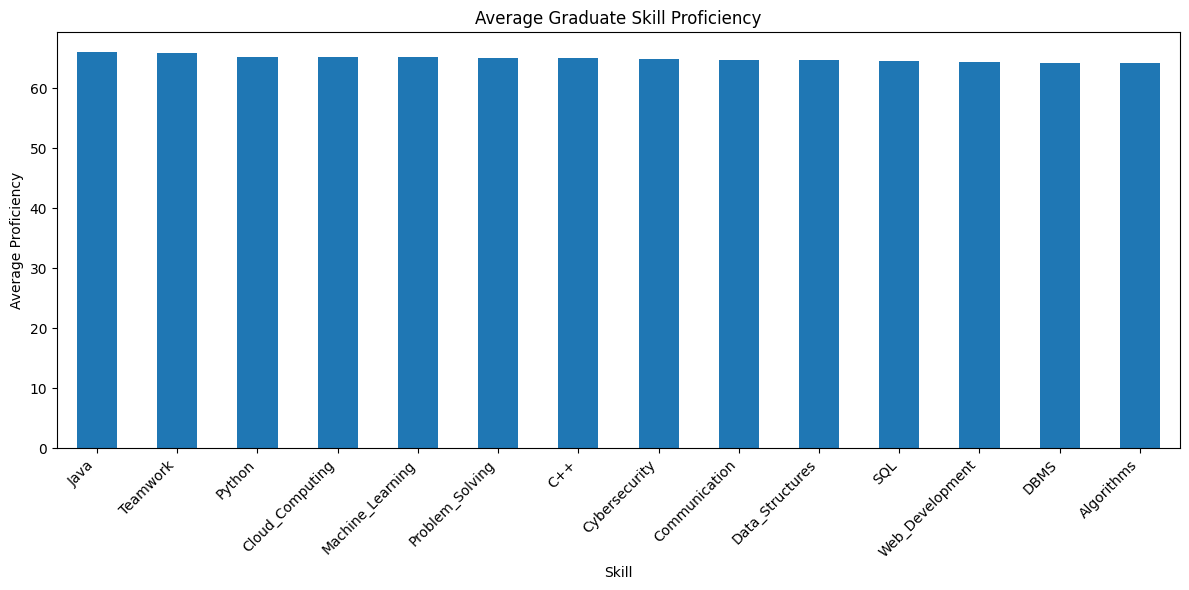

In [ ]:
plt.figure(figsize=(12, 6))

df[all_skills].mean().sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Average Graduate Skill Proficiency")
plt.ylabel("Average Proficiency")
plt.xlabel("Skill")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Graduate_Proficiency": [
        df[skill].mean() for skill in all_skills
    ],
    "Industry_Demand": [
        industry_demand[skill] for skill in all_skills
    ]
}, index=all_skills)

comparison

,Graduate_Proficiency,Industry_Demand
Python,65.230348,85
Java,66.012936,75
C++,65.012630,70
Data_Structures,64.680307,90
Algorithms,64.219167,88
DBMS,64.230729,82
SQL,64.515582,84
Machine_Learning,65.214699,80
Cloud_Computing,65.214975,78
Cybersecurity,64.808982,70


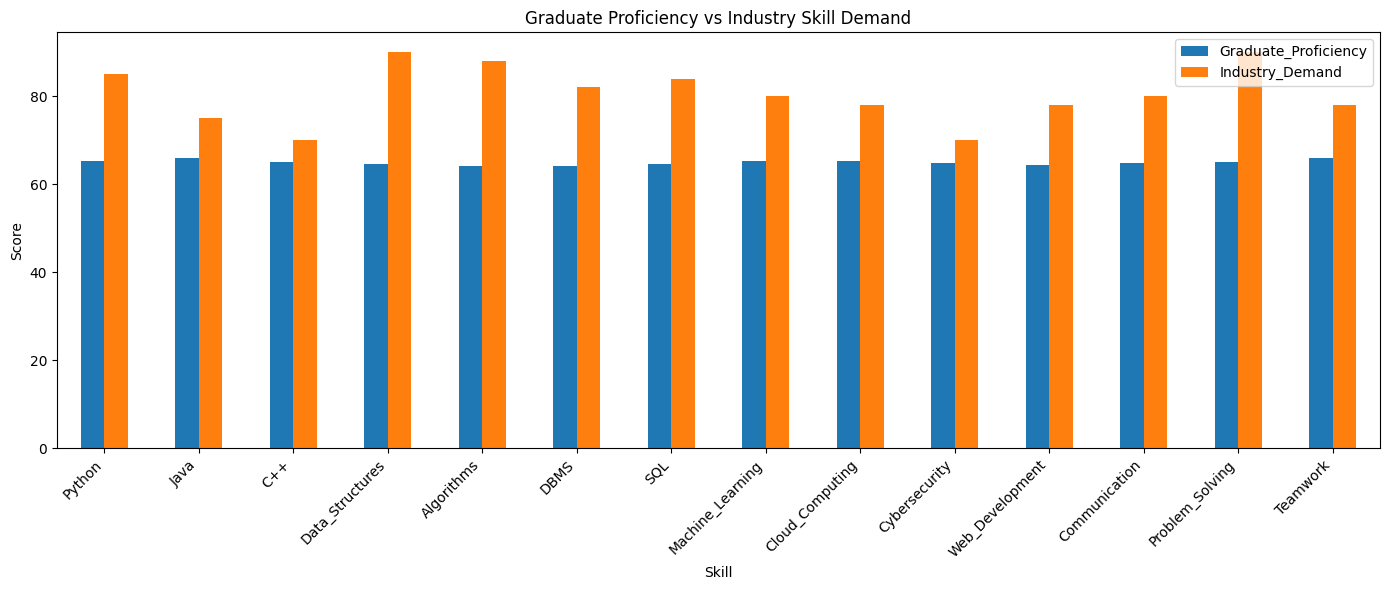

In [ ]:
comparison.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Graduate Proficiency vs Industry Skill Demand")
plt.ylabel("Score")
plt.xlabel("Skill")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
comparison["Gap"] = (
    comparison["Industry_Demand"]
    - comparison["Graduate_Proficiency"]
)

comparison = comparison.sort_values(
    "Gap",
    ascending=False
)

comparison

,Graduate_Proficiency,Industry_Demand,Gap
Data_Structures,64.680307,90,25.319693
Problem_Solving,65.082063,90,24.917937
Algorithms,64.219167,88,23.780833
Python,65.230348,85,19.769652
SQL,64.515582,84,19.484418
DBMS,64.230729,82,17.769271
Communication,64.773288,80,15.226712
Machine_Learning,65.214699,80,14.785301
Web_Development,64.374779,78,13.625221
Cloud_Computing,65.214975,78,12.785025


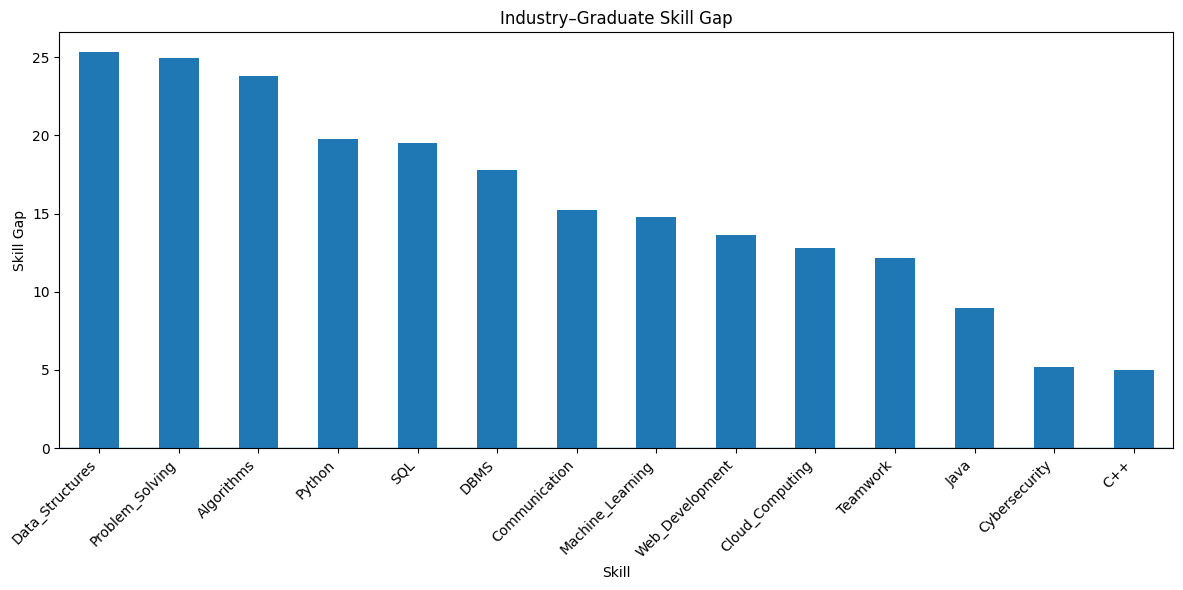

In [ ]:
plt.figure(figsize=(12, 6))

comparison["Gap"].plot(kind="bar")

plt.axhline(
    0,
    linewidth=1
)

plt.title("Industry–Graduate Skill Gap")
plt.ylabel("Skill Gap")
plt.xlabel("Skill")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
features = all_skills + [
    "CGPA",
    "Projects",
    "Internship",
    "Certifications"
]

X = df[features]

y = df["Employability_Status"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.965
Precision: 0.9811
Recall   : 0.975
F1 Score : 0.9781


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Needs Improvement",
        "Job Ready"
    ]
))

                   precision    recall  f1-score   support

Needs Improvement       0.90      0.93      0.91        40
        Job Ready       0.98      0.97      0.98       160

         accuracy                           0.96       200
        macro avg       0.94      0.95      0.95       200
     weighted avg       0.97      0.96      0.97       200



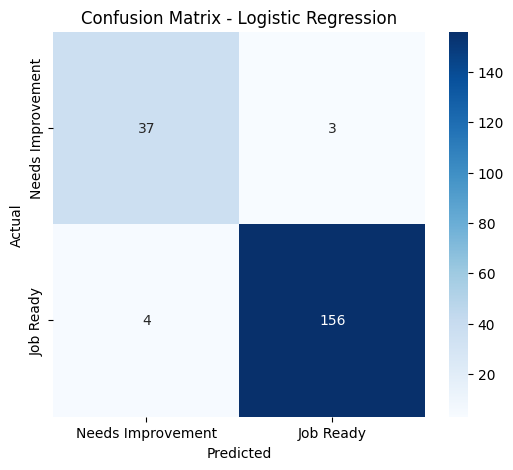

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Needs Improvement",
        "Job Ready"
    ],
    yticklabels=[
        "Needs Improvement",
        "Job Ready"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Importance"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Importance",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Importance
7,Machine_Learning,1.863983,1.863983
3,Data_Structures,1.859014,1.859014
12,Problem_Solving,1.835045,1.835045
4,Algorithms,1.812206,1.812206
6,SQL,1.803616,1.803616
0,Python,1.786763,1.786763
13,Teamwork,1.753070,1.753070
8,Cloud_Computing,1.592313,1.592313
10,Web_Development,1.589410,1.589410
2,C++,1.545793,1.545793


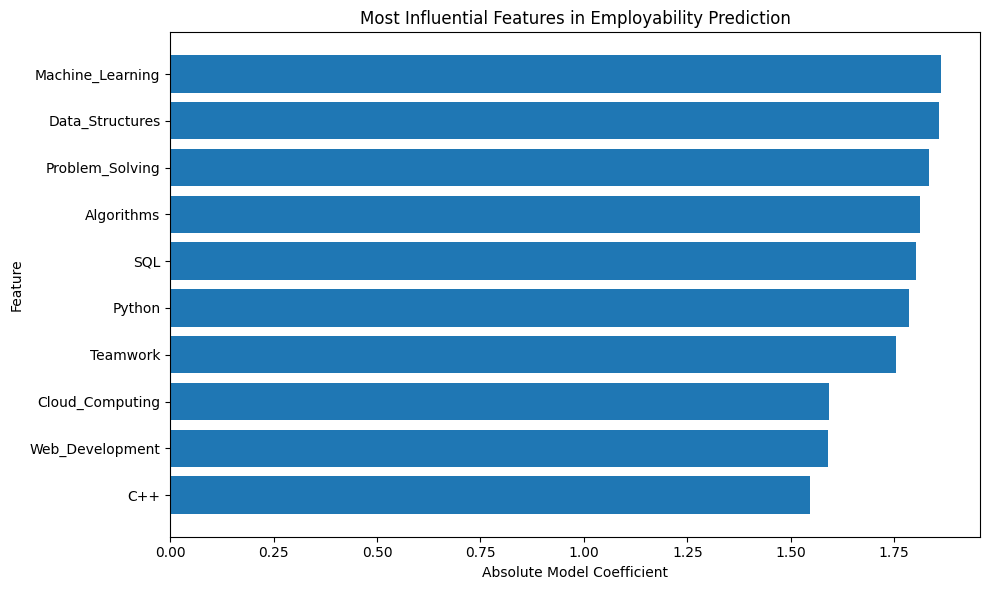

In [ ]:
top_features = coefficients.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Importance"]
)

plt.xlabel("Absolute Model Coefficient")
plt.ylabel("Feature")
plt.title("Most Influential Features in Employability Prediction")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
comparison["Priority"] = pd.cut(
    comparison["Gap"],
    bins=[-np.inf, 5, 15, np.inf],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

comparison

,Graduate_Proficiency,Industry_Demand,Gap,Priority
Data_Structures,64.680307,90,25.319693,High
Problem_Solving,65.082063,90,24.917937,High
Algorithms,64.219167,88,23.780833,High
Python,65.230348,85,19.769652,High
SQL,64.515582,84,19.484418,High
DBMS,64.230729,82,17.769271,High
Communication,64.773288,80,15.226712,High
Machine_Learning,65.214699,80,14.785301,Medium
Web_Development,64.374779,78,13.625221,Medium
Cloud_Computing,65.214975,78,12.785025,Medium


In [ ]:
comparison.sort_values(
    "Gap",
    ascending=False
)

,Graduate_Proficiency,Industry_Demand,Gap,Priority
Data_Structures,64.680307,90,25.319693,High
Problem_Solving,65.082063,90,24.917937,High
Algorithms,64.219167,88,23.780833,High
Python,65.230348,85,19.769652,High
SQL,64.515582,84,19.484418,High
DBMS,64.230729,82,17.769271,High
Communication,64.773288,80,15.226712,High
Machine_Learning,65.214699,80,14.785301,Medium
Web_Development,64.374779,78,13.625221,Medium
Cloud_Computing,65.214975,78,12.785025,Medium


In [ ]:
student = df.iloc[0]

student_gaps = pd.DataFrame({
    "Skill": all_skills,
    "Graduate_Score": [
        student[skill] for skill in all_skills
    ],
    "Industry_Demand": [
        industry_demand[skill] for skill in all_skills
    ],
    "Gap": [
        student[f"{skill}_Gap"] for skill in all_skills
    ]
})

student_gaps = student_gaps.sort_values(
    "Gap",
    ascending=False
)

student_gaps

,Skill,Graduate_Score,Industry_Demand,Gap
3,Data_Structures,36.382887,90,53.617113
4,Algorithms,52.047596,88,35.952404
6,SQL,48.288780,84,35.711220
11,Communication,47.327305,80,32.672695
5,DBMS,58.643605,82,23.356395
10,Web_Development,54.822579,78,23.177421
2,C++,54.872326,70,15.127674
8,Cloud_Computing,64.504621,78,13.495379
13,Teamwork,65.176046,78,12.823954
0,Python,72.450712,85,12.549288


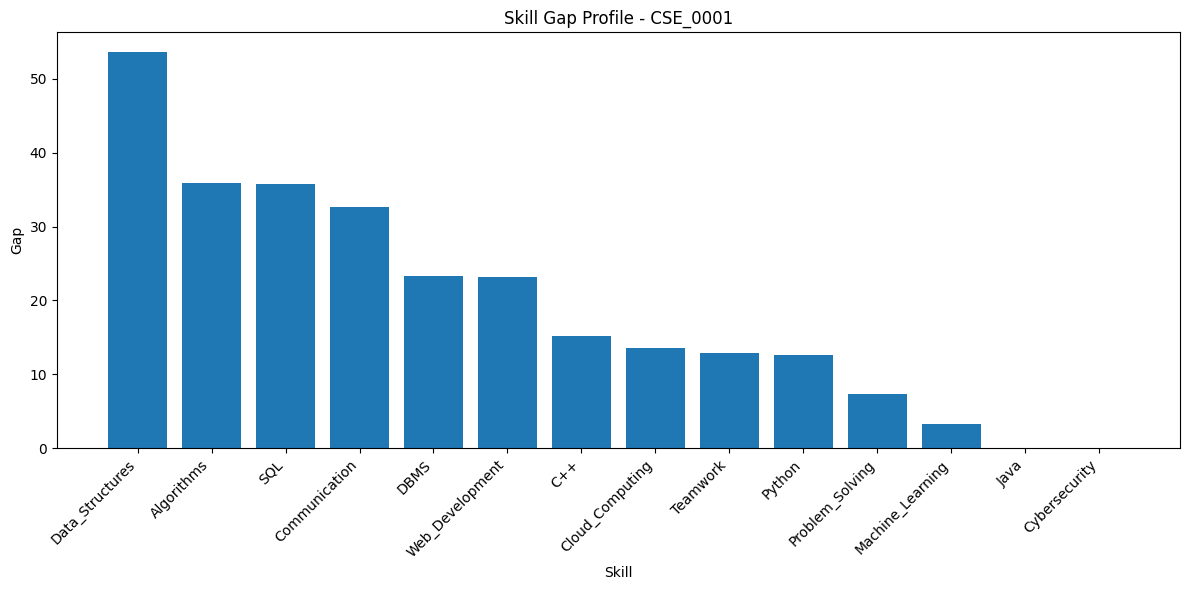

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    student_gaps["Skill"],
    student_gaps["Gap"]
)

plt.title(
    f"Skill Gap Profile - {student['Student_ID']}"
)

plt.ylabel("Gap")
plt.xlabel("Skill")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()